In [2]:
import earthaccess,csv
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy.ndimage import generic_filter
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
from scipy.ndimage import median_filter
from scipy.interpolate import LinearNDInterpolator
from scipy.ndimage import generic_filter
import widetrax
from widetrax import Spectra as sp
from widetrax import DataPreprocessing as dp
from widetrax import Grads as gr
from jaxparrow import geostrophy

In [188]:
%pip install jaxparrow
from jaxparrow import cyclogeostrophy
import jax.numpy as jnp
import jaxparrow as jxr

In [21]:
# conda install conda-forge::pyinterp

In [5]:
date_requested = '20240508'
pacedate="2024-05-08"

In [6]:
aviso_ds = xr.open_dataset('data/eddy_trajectories/Edward_Eddy_trajectory_nrt_3.2exp_cyclonic_20180101_20240723.nc')

In [7]:
dates = [i for i in aviso_ds.time.values] # these are sorted already
print(min(dates))
print(max(dates)) # still existed at the end of the dataset
tminny=str(min(dates))
tminny=tminny[0:10]
tmaxxy=str(max(dates))
tmaxxy=tmaxxy[0:10]
tmin,tmax = tminny,tmaxxy
center_lats = [i for i in aviso_ds.latitude.values]
center_lons = [i for i in aviso_ds.longitude.values]
print(len(center_lats))
print(min(center_lats))
print(max(center_lats))
print(min(center_lons)-360)
print(max(center_lons)-360)
#Define box based on eddy
latmin,latmax = min(center_lats)-2,max(center_lats)+2
lonmin,lonmax = min(center_lons)-360-2,max(center_lons)-360+2

2023-12-14T00:00:00.000000000
2024-07-23T00:00:00.000000000
223
35.502697
36.847385
-71.77411
-67.887146


In [8]:
auth = earthaccess.login(persist=True)

In [9]:
def get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax):
    """
    Searches for SWOT data within the bounding box and time. Note that this doesn't work for unsmoothed data. 
    
    latmin,latmax: latitude bounds, degrees N (south is negative); floats
    lonmin, lonmax: longitude bounds, degrees E (west is negative); floats
    tmin,tmax: temporal bounds; strings of form 'yyyy-mm-dd'
    """
    bbox = (lonmin, latmin, lonmax, latmax) # lonW, latS, lonE, latN
    results = earthaccess.search_data(
        short_name="SWOT_L2_LR_SSH_EXPERT_2.0",
        bounding_box=bbox,
        temporal=(tmin,tmax))
    
    print("Number of swaths: " + str(len(results))) # not daily files, so will likely be more than # of days
    paths = earthaccess.open(results) # is there a way to choose a subset of variables here?

    return paths

In [10]:
eddy_paths = get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax)

Number of swaths: 242


QUEUEING TASKS | :   0%|          | 0/242 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/242 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/242 [00:00<?, ?it/s]

In [11]:
ind = 0 
for i in eddy_paths:
    today = str(i).split('-')[-1].split('_')[-4][0:8]
    if date_requested == today:
        print(ind)
        sel=ind
    ind += 1

166
167


In [12]:
ds1 = xr.open_dataset(eddy_paths[sel])
ds2 = xr.open_dataset(eddy_paths[sel-1])

In [13]:
def crop_dataset_by_lat_lon(ds,latmin,latmax,lonmin,lonmax):
    mask = (ds.latitude >= latmin) & (ds.latitude <= latmax) & (ds.longitude >= lonmin+360) & (ds.longitude <= lonmax+360)
    ds_masked = ds.where(mask, drop=True)
    return ds_masked

In [14]:
ds1_masked = crop_dataset_by_lat_lon(ds1,latmin,latmax,lonmin,lonmax)
ds2_masked = crop_dataset_by_lat_lon(ds2,latmin,latmax,lonmin,lonmax)

In [15]:
ds=ds1_masked
ssh=ds.ssha_karin_2+ds.height_cor_xover
lats=ds.latitude
lons=ds.longitude
ds=ds.assign(ssha=ssh)

In [16]:
ds2=ds2_masked
ssh2=ds2.ssha_karin_2+ds.height_cor_xover
lats2=ds2.latitude
lons2=ds2.longitude
ds2=ds2.assign(ssha=ssh2)

In [92]:
ug, vg, j, j1, j12, j3 = geostrophy(jnp.array(ssh),jnp.array(lats),jnp.array(lons))
ug2, vg2, j, j1, j12, j3 = geostrophy(jnp.array(ssh2),jnp.array(lats2),jnp.array(lons2)) #they inversed this!

In [98]:
u_cyclo_2d, v_cyclo_2d, j, j1, j12, j3 =cyclogeostrophy(jnp.array(ssh),jnp.array(lats),jnp.array(lons))
u_cyclo_2d_2, v_cyclo_2d_2, j, j1, j12, j3 =cyclogeostrophy(jnp.array(ssh2),jnp.array(lats2),jnp.array(lons2))

In [ ]:
# Remove edge of swath due to edge effects in vg and v_cyclo. Please note that this function was written with the assistance of AI
def remove_swath_edges(data_array, edge_pixels):
    """
    Remove edge pixels from SWOT swath - optimized version
    """
    # Directly set edge pixels to NaN without creating a separate mask
    result = data_array.at[:, :edge_pixels].set(jnp.nan)
    result = result.at[:, -edge_pixels:].set(jnp.nan)
    return result

In [ ]:
pixel_num=5 #This number will change per 
ug = remove_swath_edges(ug, edge_pixels=pixel_num)
ug2 = remove_swath_edges(ug2, edge_pixels=pixel_num)
vg = remove_swath_edges(vg, edge_pixels=pixel_num)
vg2 = remove_swath_edges(vg2, edge_pixels=pixel_num)

In [99]:
pixel_num=5 #This number will change per 
ucyclo = remove_swath_edges(u_cyclo_2d, edge_pixels=pixel_num)
ucyclo2 = remove_swath_edges(u_cyclo_2d_2, edge_pixels=pixel_num)
vcyclo = remove_swath_edges(v_cyclo_2d, edge_pixels=pixel_num)
vcyclo2 = remove_swath_edges(v_cyclo_2d_2, edge_pixels=pixel_num)

In [102]:
#Clean up cyclogeostrophic velocities. Artifacts above 5 m/s (also, unrealistic?)
ucyclo=np.array(ucyclo)
ucyclo[np.abs(ucyclo) > 5] = np.nan

ucyclo2=np.array(ucyclo2)
ucyclo2[np.abs(ucyclo2) > 5] = np.nan

vcyclo=np.array(vcyclo)
vcyclo[np.abs(vcyclo) > 5] = np.nan

vcyclo2=np.array(vcyclo2)
vcyclo2[np.abs(vcyclo2) > 5] = np.nan

<Figure size 640x480 with 0 Axes>

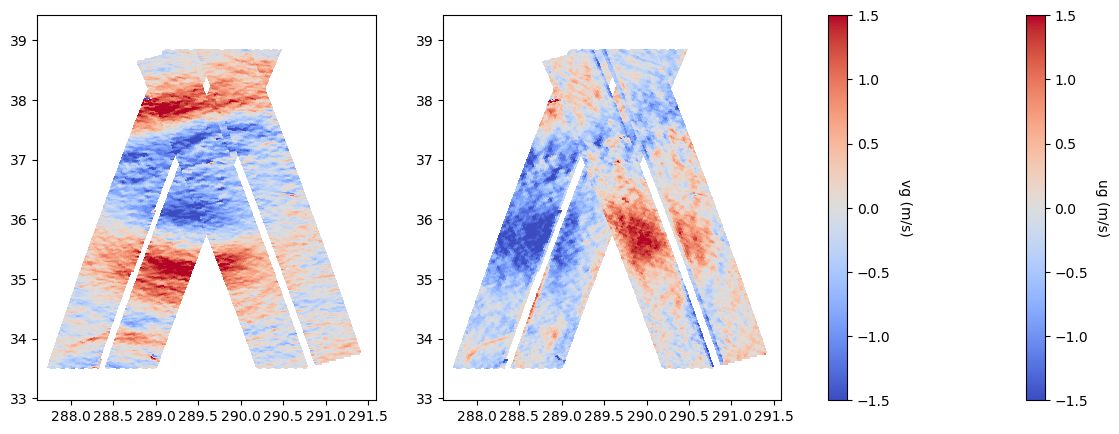

In [142]:
vel=1.5
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(15,5))

plot = ax[0].pcolormesh(lons,lats,ug,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons2,lats2,-ug2,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('ug (m/s)', rotation=270, labelpad=15)

# plot = ax.pcolormesh(grid_x,grid_y,ug2,cmap='coolwarm',vmin=-1,vmax=1)
# ax.plot(contour_lons,contour_lats,zorder=100,c='k',linewidth=2)


plot = ax[1].pcolormesh(lons,lats,vg,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,-vg2,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('vg (m/s)', rotation=270, labelpad=15)

<Figure size 640x480 with 0 Axes>

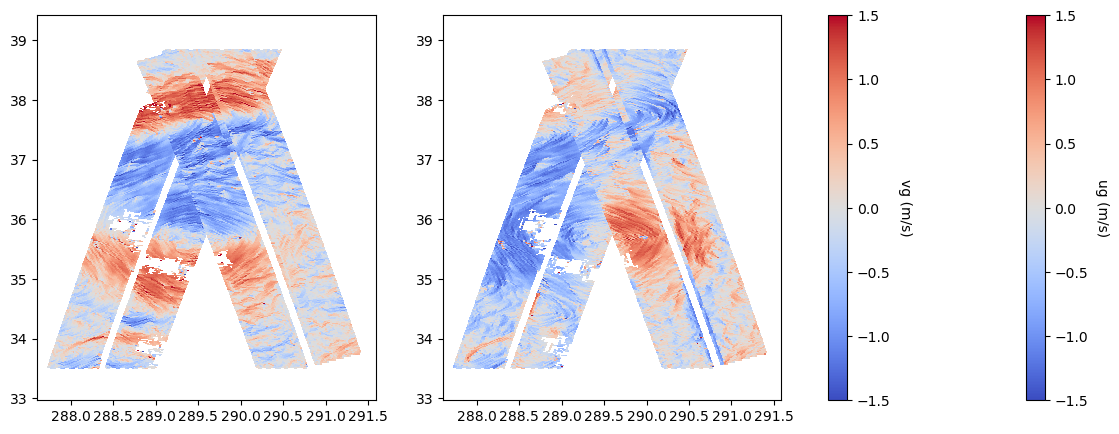

In [141]:
vel=1.5
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(15,5))

plot = ax[0].pcolormesh(lons,lats,ucyclo,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons2,lats2,-ucyclo2,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('ug (m/s)', rotation=270, labelpad=15)

# plot = ax.pcolormesh(grid_x,grid_y,ug2,cmap='coolwarm',vmin=-1,vmax=1)
# ax.plot(contour_lons,contour_lats,zorder=100,c='k',linewidth=2)


plot = ax[1].pcolormesh(lons,lats,vcyclo,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,-vcyclo2,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('vg (m/s)', rotation=270, labelpad=15)

In [255]:
# Compare geostrophic vorticity with vorticity calculated from cyclogeostrophic currents
def compute_normalized_vorticity_strain(data_array,u,v,wfl):

    lats = jnp.array(data_array.latitude.values)
    lons = jnp.array(data_array.longitude.values)

    dx, dy = jxr.tools.geometry.compute_spatial_step(lats, lons)
    mask = np.zeros_like(u)

    #Smoothing code is under construction here... this snippet of smoothing code written with help of AI (as you can likely tell...)
    #I'm still trying to figure out why just simply running the generic filter on u and v is cutting the swath substantially, whereas this code retains swath width...
    #I'll come back to this, but it does work well for now.
    def direct_2d_swath_smoothing(u_geos_u, lat, lon, window_size=5, angle_tolerance=30):
        """
        Modified version of your original code for 2D smoothing
        """
        # Calculate track direction (same as original)
        dy = np.gradient(lat, axis=0)
        dx = np.gradient(lon, axis=0)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            track_angle = np.arctan2(dy, dx)
            track_angle = np.nan_to_num(track_angle, nan=0.0)
        
        # Use the same window size for both directions
        footprint = np.ones((window_size, window_size), dtype=bool)
        
        def simple_2d_filter(values):
            """Simplified 2D version of your original filter"""
            center_idx = len(values) // 2
            if np.isnan(values[center_idx]):
                return np.nan
            
            # Get center point's track angle
            center_angle = track_angle.flat[center_idx]
            
            # Calculate angular differences
            window_angles = track_angle.flat[:len(values)]
            angle_diffs = np.abs(window_angles - center_angle)
            angle_diffs = np.minimum(angle_diffs, 2*np.pi - angle_diffs)
            
            # Create mask for points along track
            along_track_mask = angle_diffs < np.radians(angle_tolerance)
            valid_mask = ~np.isnan(values)
            
            # Use ALL valid points along track (no distance weighting)
            final_mask = along_track_mask & valid_mask
            
            if np.any(final_mask):
                return np.mean(values[final_mask])  # Simple average
            else:
                return values[center_idx]
    
        smoothed = generic_filter(u_geos_u, simple_2d_filter, footprint=footprint, mode='nearest', cval=np.nan)
        # Apply the filter (this now does 2D smoothing following swath direction)
        return smoothed
   
    # u=generic_filter(u, np.mean, size=[wfl,wfl], mode='nearest')
    # v=generic_filter(v, np.mean, size=[wfl,wfl], mode='nearest')

    u=direct_2d_swath_smoothing(u, lats, lons, window_size=wfl)
    v=direct_2d_swath_smoothing(v, lats, lons, window_size=wfl)

    # Compute derivatives
    dv_dx = jxr.tools.operators.derivative(v, dx, mask=mask, axis=1, padding="right")  # ∂v/∂x
    du_dy = jxr.tools.operators.derivative(u, dy, mask=mask, axis=0, padding="right")  # ∂u/∂y

    du_dx = jxr.tools.operators.derivative(u, dx, mask=mask, axis=1, padding="right")  # ∂v/∂x
    dv_dy = jxr.tools.operators.derivative(v, dy, mask=mask, axis=0, padding="right")  # ∂u/∂y

    #Compute coriolis for normalization
    omega = 7.2921159e-05  # angular velocity of the Earth [rad/s]
    fc = 2*omega*np.sin(lats*np.pi/180.)
        
    # avoid zero near equator, bound fc by min val as 1.e-8
    f_coriolis = np.sign(fc)*np.maximum(np.abs(fc), 1.e-8)

    vorticity = dv_dx - du_dy / f_coriolis
    strain= np.sqrt((du_dx - dv_dy)**2 + (du_dy + dv_dx) ** 2)
    strain=strain/f_coriolis 

    return vorticity,strain

In [256]:
vort,strain=compute_normalized_vorticity_strain(ds,ug,vg,10)
vort2,strain2=compute_normalized_vorticity_strain(ds2,ug2,vg2,10) 

(33.7, 39.0)

<Figure size 640x480 with 0 Axes>

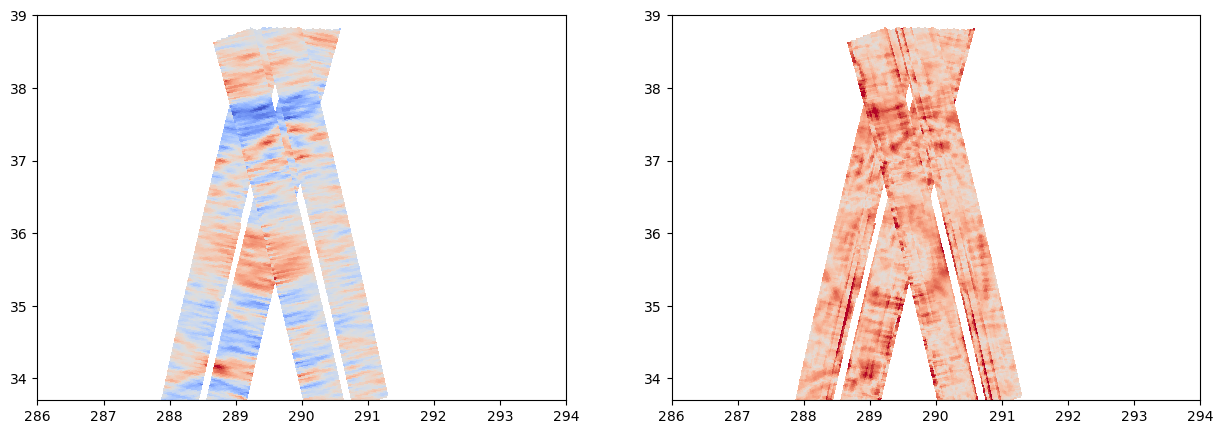

In [235]:
vel=1
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(15,5))

plot = ax[0].pcolormesh(lons,lats,vort,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons2,lats2,vort2,cmap='coolwarm',vmin=-vel,vmax=vel)
# cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('vorticity/f', rotation=270, labelpad=15)

plot = ax[1].pcolormesh(lons,lats,strain,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,strain2,cmap='coolwarm',vmin=-vel,vmax=vel)
# cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('strain/f', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39 ])

ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39 ])

In [266]:
vort,strain=compute_normalized_vorticity_strain(ds,ucyclo,vcyclo,5)
vort2,strain2=compute_normalized_vorticity_strain(ds2,ucyclo2,vcyclo2,5) 

(33.7, 39.0)

<Figure size 640x480 with 0 Axes>

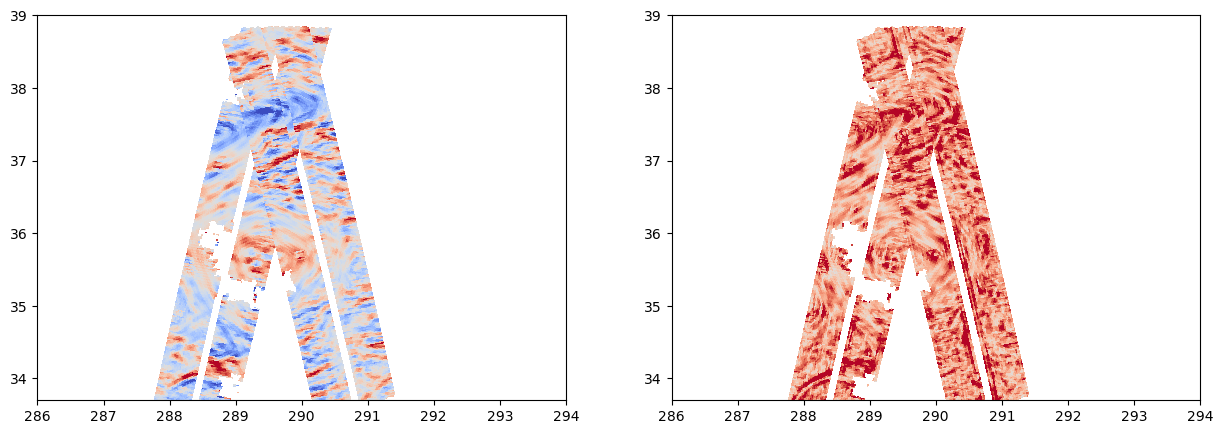

In [183]:
vel=1
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(15,5))

plot = ax[0].pcolormesh(lons,lats,vort,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons2,lats2,vort2,cmap='coolwarm',vmin=-vel,vmax=vel)
# cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('vorticity/f', rotation=270, labelpad=15)

plot = ax[1].pcolormesh(lons,lats,strain,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,strain2,cmap='coolwarm',vmin=-vel,vmax=vel)
# cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('strain/f', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39 ])

ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39 ])